# T002 · 分子筛选：ADME 和类先导化合物标准

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域技能，并为研究项目提供管道模板作为起点。

作者：

- Michele Wichmann, CADD seminar, 2017, Charité/FU Berlin
- Mathias Wajnberg, CADD seminar, 2018, Charité/FU Berlin
- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)

__教程 T002__：本教程是 [首篇 TeachOpenCADD 论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x) 中描述的 TeachOpenCADD 流程的一部分，包括 T001-T010 教程。

## 本教程目标

在药物设计背景下，根据物理化学性质筛选候选分子非常重要。在本教程中，从 ChEMBL 获取的化合物（__教程 T001__）将根据 Lipinski 的"五规则"进行筛选，以仅保留口服生物可利用的化合物。此外，我们将创建雷达图来以可视化方式显示化合物满足各个标准的程度。

### 理论内容

* ADME - 吸收、分布、代谢和排泄
* 类先导化合物和 Lipinski 的"五规则"（Ro5）
* 类先导化合物背景下的雷达图

### 实践内容

* 定义和可视化示例分子
* 计算和绘制 Ro5 相关的分子性质
* 检查是否符合 Ro5
* 将 Ro5 应用于 EGFR 数据集
* 使用雷达图可视化 Ro5 性质

### 参考文献

* ADME 标准（[Wikipedia](https://en.wikipedia.org/wiki/ADME) 和 [<i>Mol Pharm.</i> (2010), <b>7(5)</b>, 1388-1405](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3025274/)）
* [SwissADME](https://www.nature.com/articles/srep42717)：免费网络工具，可评估大量 ADME 相关参数
* 基于 RDKit 的 ADME 过滤器（[repository](https://github.com/rdkit/rdkit/tree/master/Contrib/IFP)）
* 类先导化合物标准：[Lipinski *et al.*, <i>Adv. Drug. Deliv. Rev.</i> (1997), <b>23</b>, 3-25](https://www.sciencedirect.com/science/article/abs/pii/S0169409X96004231)

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 2
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

在虚拟筛选中，我们旨在预测化合物是否可能与特定靶标结合并相互作用。然而，如果我们想鉴定一种新药，该化合物在人体中的行为也很重要，即其药代动力学概貌。为此，ADME（吸收、分布、代谢和排泄）描述符被广泛使用。如果一种化合物不符合这些要求，该化合物很可能无法成为先导化合物，即可能无法被开发为药物。在这种情况下，筛选相关的物理化学性质有助于减少待测试化合物的数量，从而减少药物开发过程中的费用和精力。

### ADME - 吸收、分布、代谢和排泄

药代动力学主要分为四个步骤：
<strong>A</strong>吸收（<strong>A</strong>bsorption）、
<strong>D</strong>分布（<strong>D</strong>istribution）、
<strong>M</strong>代谢（<strong>M</strong>etabolism）和
<strong>E</strong>排泄（<strong>E</strong>xcretion）。
这些步骤共同决定了该化合物是否适用于作为药物。

__吸收__：药物进入体内的数量和时间取决于多个因素，这些因素可能因个体及其状况而异，也取决于物质的性质。吸收的主要因素包括溶解度、渗透性、稳定性和适当的生物利用度。

__分布__：被吸收物质的分布，即在体内、血液和不同组织之间以及穿过血脑屏障，受区域血流量、分子大小和极性以及与血清蛋白结合的影响。仔细分析一个分子的分布概况很重要，因为代谢物可能在预期靶标区域之外分布，并引起副作用。

__代谢__：进入体内后，化合物将被代谢。这意味着只有部分化合物会真正到达其靶标。主要是肝脏和肾脏酶负责这一过程。在寻找药物时，重要的是确保这些代谢物不被激活为毒性或反应性物质。

__排泄__：化合物及其代谢物需要通过排泄从体内清除，通常通过肾脏（尿液）或粪便排出。不完全排泄可能导致外来物质在体内蓄积，对身体造成长期损害。

![ADME processes in the human body](images/adme.png)

_图 1_：人体中的 ADME 过程（图取自 [Openclipart](https://openclipart.org/) 并修改）。

### 类先导化合物和 Lipinski 的"五规则"（Ro5）

[<strong>先导</strong>化合物](https://en.wikipedia.org/wiki/Lead_compound) 是具有前景特性的开发中候选药物。它们在成为药物之前，通常会在开发过程中进行优化。在先导化合物的优化过程中，重要的是保持有利的物理化学性质，以提高药物在人体内的成功几率。为此，开发了基于 ADME 的筛选标准。这些标准中最著名、最广泛使用的是 Lipinski 的"五规则"（Ro5），由 Christopher Lipinski 及其同事在 1997 年提出，用于估计口服给药后化合物的生物利用度。

### 类先导化合物背景下的雷达图

分子性质（如 Ro5 性质）可以通过多种方式可视化（例如 Craig 图、花图或黄金三角），以支持针对多参数优化问题的化合物比较和选择。在本教程中，我们使用[雷达图](https://en.wikipedia.org/wiki/Radar_chart)，其中物理化学性质轴从中心点径向排列，使得中心点代表最低值，外圈代表最高值。这样，可以可视化不同分子或不同数据集在分子性质多样性方面的差异。

## 实践

In [2]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, PandasTools

In [3]:
# 设置本 notebook 的路径
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 定义和可视化示例分子

在处理从 ChEMBL 获取的整个数据集之前，我们选取四个示例化合物来研究它们的化学性质。我们通过 SMILES 绘制四个示例分子。

In [4]:
smiles = [
    "CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(C(=O)NC(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N1)C(C(C)CC=CC)O)C)C(C)C)C)CC(C)C)C)CC(C)C)C)C)C)CC(C)C)C)C(C)C)CC(C)C)C)C",
    "CN1CCN(CC1)C2=C3C=CC=CC3=NC4=C(N2)C=C(C=C4)C",
    "CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC=CC=C(C)C=CC=C(C)C=CC2=C(CCCC2(C)C)C)C)C",
    "CCCCCC1=CC(=C(C(=C1)O)C2C=C(CCC2C(=C)C)C)O",
]
names = ["cyclosporine", "clozapine", "beta-carotene", "cannabidiol"]

首先，我们将分子的名称和 SMILES 连同其结构组合在一个 DataFrame 中。

,name,smiles,ROMol
0,cyclosporine,CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(...,
1,clozapine,CN1CCN(CC1)C2=C3C=CC=CC3=NC4=C(N2)C=C(C=C4)C,
2,beta-carotene,CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC=CC=C(C)C=CC=...,
3,cannabidiol,CCCCCC1=CC(=C(C(=C1)O)C2C=C(CCC2C(=C)C)C)O,

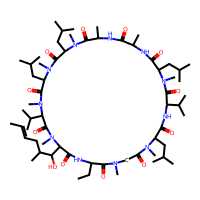
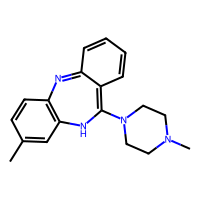
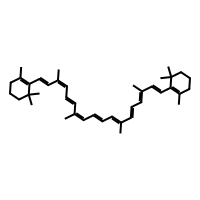
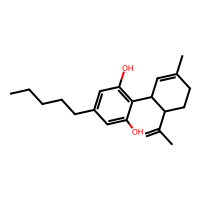

In [5]:
molecules = pd.DataFrame({"name": names, "smiles": smiles})
PandasTools.AddMoleculeColumnToFrame(molecules, "smiles")
molecules

### 计算和绘制 Ro5 相关的分子性质

1. 使用一些 [descriptors](http://www.rdkit.org/docs/GettingStartedInPython.html#list-of-available-descriptors) 计算分子量、氢键受体的数量、氢键供体的数量和 logP。

In [6]:
molecules["molecular_weight"] = molecules["ROMol"].apply(Descriptors.ExactMolWt)
molecules["n_hba"] = molecules["ROMol"].apply(Descriptors.NumHAcceptors)
molecules["n_hbd"] = molecules["ROMol"].apply(Descriptors.NumHDonors)
molecules["logp"] = molecules["ROMol"].apply(Descriptors.MolLogP)
# 颜色用于稍后绘制分子
molecules["color"] = ["red", "green", "blue", "cyan"]
# NBVAL_CHECK_OUTPUT
molecules[["molecular_weight", "n_hba", "n_hbd", "logp"]]

,molecular_weight,n_hba,n_hbd,logp
0,1201.841368,12,5,3.26900
1,306.184447,4,1,1.68492
2,536.438202,0,0,12.60580
3,314.224580,2,2,5.84650


,name,smiles,ROMol,molecular_weight,n_hba,n_hbd,logp,color
0,cyclosporine,CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(...,,1201.841368,12,5,3.26900,red
1,clozapine,CN1CCN(CC1)C2=C3C=CC=CC3=NC4=C(N2)C=C(C=C4)C,,306.184447,4,1,1.68492,green
2,beta-carotene,CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC=CC=C(C)C=CC=...,,536.438202,0,0,12.60580,blue
3,cannabidiol,CCCCCC1=CC(=C(C(=C1)O)C2C=C(CCC2C(=C)C)C)O,,314.224580,2,2,5.84650,cyan

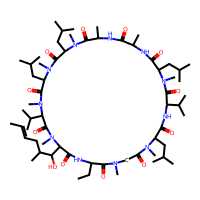
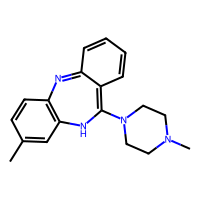
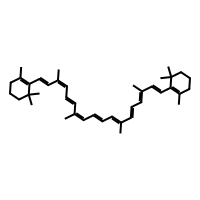
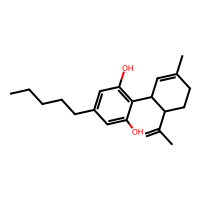

In [7]:
# 完整预览
molecules

2. 将分子性质绘制为条形图。

In [8]:
ro5_properties = {
    "molecular_weight": (500, "molecular weight (Da)"),
    "n_hba": (10, "# HBA"),
    "n_hbd": (5, "# HBD"),
    "logp": (5, "logP"),
}

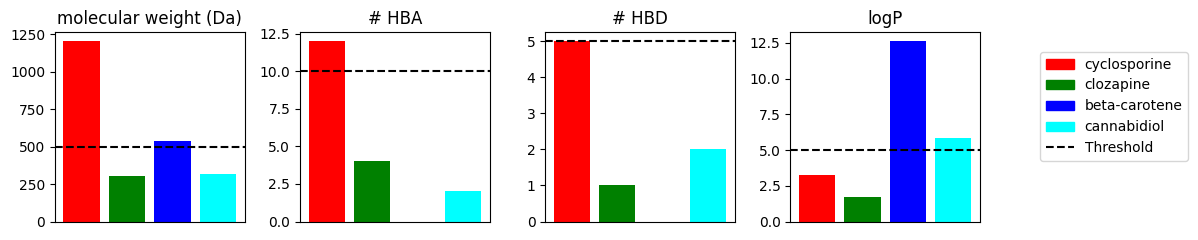

In [9]:
# 开始 1x4 绘图框架
fig, axes = plt.subplots(figsize=(10, 2.5), nrows=1, ncols=4)
x = np.arange(1, len(molecules) + 1)
colors = ["red", "green", "blue", "cyan"]

# 创建子图
for index, (key, (threshold, title)) in enumerate(ro5_properties.items()):
    axes[index].bar([1, 2, 3, 4], molecules[key], color=colors)
    axes[index].axhline(y=threshold, color="black", linestyle="dashed")
    axes[index].set_title(title)
    axes[index].set_xticks([])

# 添加图例
legend_elements = [
    mpatches.Patch(color=row["color"], label=row["name"]) for index, row in molecules.iterrows()
]
legend_elements.append(Line2D([0], [0], color="black", ls="dashed", label="Threshold"))
fig.legend(handles=legend_elements, bbox_to_anchor=(1.2, 0.8))

# 将子图和图例适配到图形中
plt.tight_layout()
plt.show()

在条形图中，我们比较了四种具有不同性质的示例分子的 Ro5 性质。在接下来的步骤中，我们将检查每个化合物是否违反 Ro5。

### 检查是否符合 Ro5

In [10]:
def calculate_ro5_properties(smiles):
    """
    Test if input molecule (SMILES) fulfills Lipinski's rule of five.

    Parameters
    ----------
    smiles : str
        SMILES for a molecule.

    Returns
    -------
    pandas.Series
        Molecular weight, number of hydrogen bond acceptors/donor and logP value
        and Lipinski's rule of five compliance for input molecule.
    """
    # 从 SMILES 创建 RDKit 分子
    molecule = Chem.MolFromSmiles(smiles)
    # 计算 Ro5 相关化学性质
    molecular_weight = Descriptors.ExactMolWt(molecule)
    n_hba = Descriptors.NumHAcceptors(molecule)
    n_hbd = Descriptors.NumHDonors(molecule)
    logp = Descriptors.MolLogP(molecule)
    # 检查是否满足 Ro5 条件
    conditions = [molecular_weight <= 500, n_hba <= 10, n_hbd <= 5, logp <= 5]
    ro5_fulfilled = sum(conditions) >= 3
    # 如果违反条件不超过一个则返回 True
    return pd.Series(
        [molecular_weight, n_hba, n_hbd, logp, ro5_fulfilled],
        index=["molecular_weight", "n_hba", "n_hbd", "logp", "ro5_fulfilled"],
    )

In [11]:
# NBVAL_CHECK_OUTPUT
for name, smiles in zip(molecules["name"], molecules["smiles"]):
    print(f"Ro5 fulfilled for {name}: {calculate_ro5_properties(smiles)['ro5_fulfilled']}")

Ro5 fulfilled for cyclosporine: False
Ro5 fulfilled for clozapine: True
Ro5 fulfilled for beta-carotene: False
Ro5 fulfilled for cannabidiol: True


根据 Ro5，环孢素和β-胡萝卜素预计具有较差的口服生物利用度。然而，由于它们都是已获批药物，它们是说明 Ro5 可如何作为警示信号但不能作为严格排除标准的好例子。我们注意到 Ro5 定义中还包括另一条规则（不适用于上述分子），即化合物的 logP 不应大于 5。我们将在下面的雷达图中可视化 Ro5 性质。

### 将 Ro5 应用于 EGFR 数据集

`calculate_ro5_properties` 函数可应用于 EGFR 数据集，以筛选符合 Ro5 的化合物。

In [12]:
molecules = pd.read_csv(DATA / "EGFR_compounds.csv", index_col=0)
print(molecules.shape)
molecules.head()

(5568, 5)


,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


将 Ro5 应用于所有分子。

In [13]:
# 这需要几秒钟
ro5_properties = molecules["smiles"].apply(calculate_ro5_properties)
ro5_properties.head()

,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
0,349.021459,3,1,5.2891,True
1,387.058239,5,1,4.9333,True
2,343.043258,5,1,3.5969,True
3,339.011957,4,2,4.0122,True
4,329.027607,5,2,3.5726,True


将分子与 Ro5 数据合并。

In [14]:
molecules = pd.concat([molecules, ro5_properties], axis=1)
molecules.head()

,molecule_chembl_id,IC50,units,smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,349.021459,3,1,5.2891,True
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,387.058239,5,1,4.9333,True
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,343.043258,5,1,3.5969,True
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,339.011957,4,2,4.0122,True
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,329.027607,5,2,3.5726,True


In [15]:
# 注意 "ro5_fulfilled" 列包含布尔值
# 因此，我们可以直接使用列值来筛选数据
# 注意 ~ 对布尔值取反
molecules_ro5_fulfilled = molecules[molecules["ro5_fulfilled"]]
molecules_ro5_violated = molecules[~molecules["ro5_fulfilled"]]

print(f"# compounds in unfiltered data set: {molecules.shape[0]}")
print(f"# compounds in filtered data set: {molecules_ro5_fulfilled.shape[0]}")
print(f"# compounds not compliant with the Ro5: {molecules_ro5_violated.shape[0]}")
# NBVAL_CHECK_OUTPUT

# compounds in unfiltered data set: 5568
# compounds in filtered data set: 4635
# compounds not compliant with the Ro5: 933


In [16]:
# 保存筛选后的数据
molecules_ro5_fulfilled.to_csv(DATA / "EGFR_compounds_lipinski.csv")
molecules_ro5_fulfilled.head()

,molecule_chembl_id,IC50,units,smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,349.021459,3,1,5.2891,True
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,387.058239,5,1,4.9333,True
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,343.043258,5,1,3.5969,True
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,339.011957,4,2,4.0122,True
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,329.027607,5,2,3.5726,True


### 可视化 Ro5 性质（雷达图）

#### 计算 Ro5 性质的统计数据

定义一个辅助函数，用于计算输入 DataFrame 的均值和标准差。

In [17]:
def calculate_mean_std(dataframe):
    """
    Calculate the mean and standard deviation of a dataset.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Properties (columns) for a set of items (rows).

    Returns
    -------
    pd.DataFrame
        Mean and standard deviation (columns) for different properties (rows).
    """
    # 为性质列生成描述性统计
    stats = dataframe.describe()
    # 转置 DataFrame（统计指标 = 列）
    stats = stats.T
    # 选择均值和标准差
    stats = stats[["mean", "std"]]
    return stats

我们计算__符合 Ro5__的化合物数据集的统计数据。

In [18]:
molecules_ro5_fulfilled_stats = calculate_mean_std(
    molecules_ro5_fulfilled[["molecular_weight", "n_hba", "n_hbd", "logp"]]
)
molecules_ro5_fulfilled_stats
# NBVAL_CHECK_OUTPUT

,mean,std
molecular_weight,414.439011,87.985100
n_hba,5.996548,1.875491
n_hbd,1.889968,1.008368
logp,4.070568,1.193034


我们计算__违反 Ro5__的化合物数据集的统计数据。

In [19]:
molecules_ro5_violated_stats = calculate_mean_std(
    molecules_ro5_violated[["molecular_weight", "n_hba", "n_hbd", "logp"]]
)
molecules_ro5_violated_stats

,mean,std
molecular_weight,587.961963,101.999229
n_hba,7.963558,2.373576
n_hbd,2.301179,1.719732
logp,5.973461,1.430636


#### 定义准备雷达图数据的辅助函数

在接下来的内容中，我们将定义几个仅用于雷达图绘制的辅助函数。

__准备 y 值__：
用于 Ro5 标准的性质具有不同的数量级。
MWT 的__阈值为 500__，而 HBA 和 HBD 的数量以及 LogP 的__阈值分别为 10、5 和 5__。
为了将这些性质显示在相同的坐标轴上，需要进行缩放。

In [20]:
def _scale_by_thresholds(stats, thresholds, scaled_threshold):
    """
    Scale values for different properties that have each an individually defined threshold.

    Parameters
    ----------
    stats : pd.DataFrame
        Dataframe with "mean" and "std" (columns) for each physicochemical property (rows).
    thresholds : dict of str: int
        Thresholds defined for each property.
    scaled_threshold : int or float
        Scaled thresholds across all properties.

    Returns
    -------
    pd.DataFrame
        DataFrame with scaled means and standard deviations for each physiochemical property.
    """
    # 如果缩放键和数据统计索引不匹配则引发错误
    for property_name in stats.index:
        if property_name not in thresholds.keys():
            raise KeyError(f"Add property '{property_name}' to scaling variable.")
    # 缩放性质数据
    stats_scaled = stats.apply(lambda x: x / thresholds[x.name] * scaled_threshold, axis=1)
    return stats_scaled

__准备 x 值：__
以下辅助函数返回雷达图的__物理化学性质轴的角度__。例如，如果我们想为 4 个性质生成雷达图，我们想设置 4 个角度，其中一个角度为 0°，一个为 90°，一个为 180°，一个为 270°。如果我们想为 6 个性质生成雷达图，角度将为 0°、60°、120°、180°、240°、300°。

In [21]:
def _define_radial_axes_angles(n_axes):
    """Define angles (radians) for radial (x-)axes depending on the number of axes."""
    x_angles = [i / float(n_axes) * 2 * math.pi for i in range(n_axes)]
    x_angles += x_angles[:1]
    return x_angles

这两个函数将作为接下来定义的雷达图绘制函数中的辅助函数使用。

#### 最终生成雷达图！

现在，我们定义一个函数，以雷达图的形式可视化化合物的化学性质。
我们遵循了 [stackoverflow 上的这些说明](https://stackoverflow.com/questions/42227409/tutorial-for-python-radar-chart-intro)。

In [22]:
def plot_radar(
    y,
    thresholds,
    scaled_threshold,
    properties_labels,
    y_max=None,
    output_path=None,
):
    """
    Plot a radar chart based on the mean and standard deviation of a data set's properties.

    Parameters
    ----------
    y : pd.DataFrame
        Dataframe with "mean" and "std" (columns) for each physicochemical property (rows).
    thresholds : dict of str: int
        Thresholds defined for each property.
    scaled_threshold : int or float
        Scaled thresholds across all properties.
    properties_labels : list of str
        List of property names to be used as labels in the plot.
    y_max : None or int or float
        Set maximum y value. If None, let matplotlib decide.
    output_path : None or pathlib.Path
        If not None, save plot to file.
    """

    # 定义径向 x 轴角度 -- 使用我们的辅助函数！
    x = _define_radial_axes_angles(len(y))
    # 依据定义的阈值缩放 y 轴值 -- 使用我们的辅助函数！
    y = _scale_by_thresholds(y, thresholds, scaled_threshold)
    # 因为我们的图表是圆形的，将每个性质的第一个值追加到末尾
    y = pd.concat([y, y.head(1)])

    # 设置图形和子图轴
    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)

    # 绘制数据
    ax.fill(x, [scaled_threshold] * len(x), "cornflowerblue", alpha=0.2)
    ax.plot(x, y["mean"], "b", lw=3, ls="-")
    ax.plot(x, y["mean"] + y["std"], "orange", lw=2, ls="--")
    ax.plot(x, y["mean"] - y["std"], "orange", lw=2, ls="-.")

    # 从这里开始，我们只做图表美化
    # 将 0° 设置为 12 点钟方向
    ax.set_theta_offset(math.pi / 2)
    # 设置顺时针旋转
    ax.set_theta_direction(-1)

    # 在 180° 半径轴旁边设置 y 标签
    ax.set_rlabel_position(180)
    # 设置径向轴刻度数量并移除标签
    plt.xticks(x, [])
    # 获取最大 y 刻度值
    if not y_max:
        y_max = int(ax.get_yticks()[-1])
    # 设置轴范围
    plt.ylim(0, y_max)
    # 设置 y 轴刻度的数量和标签
    plt.yticks(
        range(1, y_max),
        ["5" if i == scaled_threshold else "" for i in range(1, y_max)],
        fontsize=16,
    )

    # 绘制 y 刻度标签以确保它们合适
    # 注意我们使用 [:1] 来排除等于第一个元素的最后一个元素（这里不需要）
    for i, (angle, label) in enumerate(zip(x[:-1], properties_labels)):
        if angle == 0:
            ha = "center"
        elif 0 < angle < math.pi:
            ha = "left"
        elif angle == math.pi:
            ha = "center"
        else:
            ha = "right"
        ax.text(
            x=angle,
            y=y_max + 1,
            s=label,
            size=16,
            horizontalalignment=ha,
            verticalalignment="center",
        )

    # 添加图例 relative to top-left plot
    labels = ("rule of five area", "mean", "mean + std", "mean - std")
    ax.legend(labels, loc=(1.1, 0.7), labelspacing=0.3, fontsize=16)

    # 保存图 - 使用 bbox_inches 包含文本框
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()

接下来，我们要为我们的两个数据集绘制雷达图：
1. 符合 Ro5 的化合物
2. 违反 Ro5 的化合物

定义对两个图保持不变的输入参数。

In [23]:
thresholds = {"molecular_weight": 500, "n_hba": 10, "n_hbd": 5, "logp": 5}
scaled_threshold = 5
properties_labels = [
    "Molecular weight (Da) / 100",
    "# HBA / 2",
    "# HBD",
    "LogP",
]
y_max = 8

1. 我们为__符合 Ro5__的化合物数据集绘制雷达图。

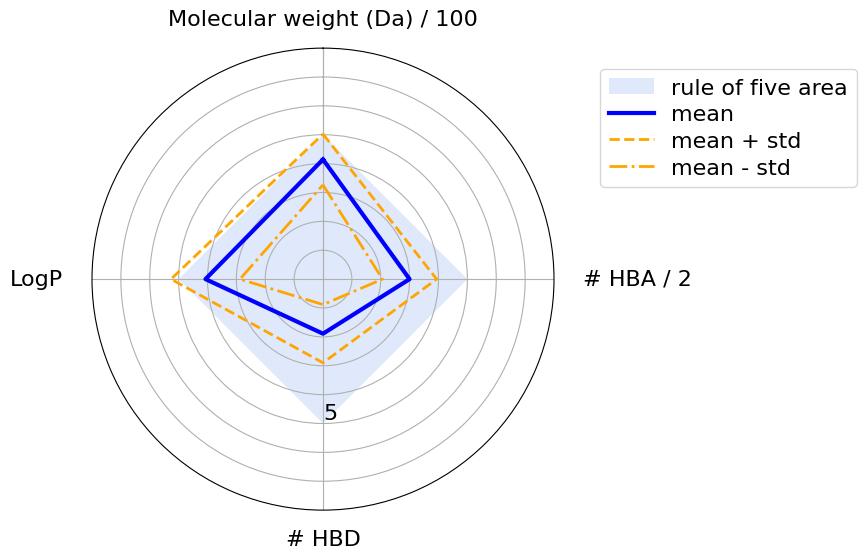

In [24]:
plot_radar(
    molecules_ro5_fulfilled_stats,
    thresholds,
    scaled_threshold,
    properties_labels,
    y_max,
)

蓝色方块显示的是分子的物理化学性质符合 Ro5 的区域。
蓝线突出显示均值，而橙色虚线显示标准偏差。我们可以看到，均值和标准偏差始终保持在 Ro5 符合区域（蓝色方块）内。

2. 我们为__违反 Ro5__的化合物数据集绘制雷达图。

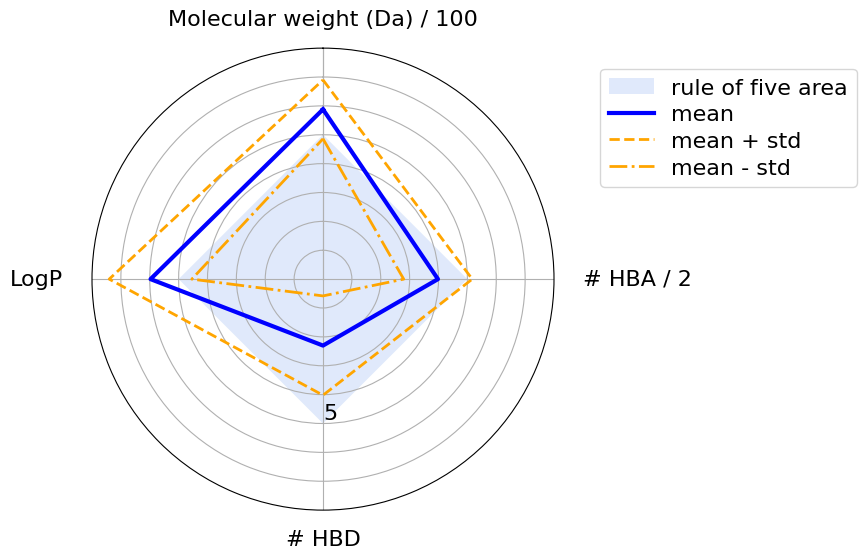

In [25]:
plot_radar(
    molecules_ro5_violated_stats,
    thresholds,
    scaled_threshold,
    properties_labels,
    y_max,
)

我们看到化合物违反 Ro5 主要是因为它们的 logP 值和分子量。

## 讨论

在本教程中，我们了解了 Lipinski 的 Ro5 作为评估化合物口服生物利用度的指标，并使用 `rdkit` 将该规则应用于数据集。
请注意，药物发现中有更广泛的 ADME 相关性质筛选标准。例如，一个常见的扩展是 Ghose 过滤器（Ghose *et al.*, <i>J. Comb. Chem.</i> (1999), <b>1</b>, 55-68），它在 Ro5 的基础上增加了更多约束。此外，SwissADME 网络工具提供了一个包括 Ro5 在内的大型 ADME 相关性质集合。

## 课后思考
* Ro5 描述的化学性质如何影响 ADME？
* 寻找或设计一个违反三条或四条规则的分子。
* 如何在雷达图中绘制额外分子的信息？